In [1]:
# Task 2 - ML Pipeline - Customer Churn Prediction
# Step 1: Libraries Import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Sab libraries ready hain! ✅")

Sab libraries ready hain! ✅


In [2]:
# Step 2: Dataset Load karo
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
print("\nPehli 5 rows:")
df.head()

Dataset Shape: (7043, 21)

Pehli 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Step 3: Data Preprocessing
# TotalCharges column numeric banao
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Missing values drop karo
df.dropna(inplace=True)

# CustomerID drop karo — ye prediction mein kaam nahi aata
df.drop('customerID', axis=1, inplace=True)

# Churn column — Yes/No ko 1/0 banao
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Baqi categorical columns encode karo
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print("Data preprocessing complete! ✅")
print("Dataset Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Data preprocessing complete! ✅
Dataset Shape: (7032, 20)

Churn Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [4]:
# Step 4: ML Pipeline banana
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline banana - Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Pipeline banana - Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Dono train karo
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Accuracy
lr_acc = accuracy_score(y_test, lr_pipeline.predict(X_test))
rf_acc = accuracy_score(y_test, rf_pipeline.predict(X_test))

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Logistic Regression Accuracy: 78.54%
Random Forest Accuracy: 79.03%


In [5]:
# Step 5: GridSearchCV - Best Parameters Dhundho
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_acc = accuracy_score(y_test, grid_search.predict(X_test))
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {best_acc*100:.2f}%")

Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 100}
Best Accuracy: 79.32%


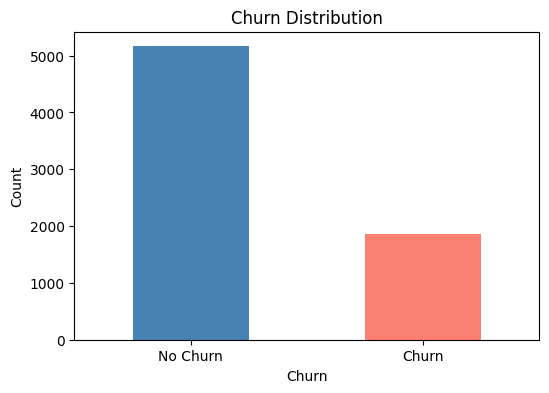

Model saved! ✅

=== FINAL RESULTS ===
Logistic Regression: 78.54%
Random Forest: 79.03%
Best Model (GridSearch): 79.32%

Task 2 Complete! ✅


In [6]:
# Step 6: Visualization + Model Save
# Churn Distribution Plot
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['No Churn', 'Churn'], rotation=0)
plt.ylabel('Count')
plt.show()

# Model joblib se save karo
joblib.dump(grid_search.best_estimator_, 'churn_pipeline.pkl')
print("Model saved! ✅")
print("\n=== FINAL RESULTS ===")
print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Random Forest: {rf_acc*100:.2f}%")
print(f"Best Model (GridSearch): {best_acc*100:.2f}%")
print("\nTask 2 Complete! ✅")